# Steering Interventions: Shape Model Behavior with Feature Vectors

Unlike interchange interventions — which swap activations between a base and counterfactual input — **steering interventions** apply a pre-computed vector directly in the model's activation space. No counterfactual input is required.

Two modes are available:

- **Replace mode** (`mode="replace"`): replaces the feature-space component of the activation with the steering vector. Setting that vector to zero is *zero ablation* — it asks "what happens if this layer's contribution is removed entirely?"
- **Add mode** (`mode="add"`): adds the vector to the base features. This pushes outputs toward a target direction without destroying existing information.

Both modes preserve the component of the base activation that is orthogonal to the feature space, so interventions are scoped to the directions you care about.

**What you will do in this notebook:**

1. Zero-ablate the residual stream layer-by-layer to identify which layers causally contribute to the output
2. Collect activations and compute a mean-difference steering vector
3. Apply additive steering at varying strengths (broadcast mode)
4. Apply per-example steering vectors to see conditional control

Section 2 then packages this into the `path_steering` analysis, which evaluates steering quality across many centroid pairs using learned manifold geometry.

In [1]:
%load_ext autoreload
%autoreload 2

# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1
DATASET_SIZE = 64

import torch
from causalab.neural.pipeline import LMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)

print(f"Model loaded on {device}")
print(f"Model has {pipeline.model.config.num_hidden_layers} layers")
print(f"Hidden size: {pipeline.model.config.hidden_size}")

`torch_dtype` is deprecated! Use `dtype` instead!


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


Model loaded on cuda
Model has 16 layers
Hidden size: 2048


## Setting up the task and dataset

We use the MCQA task with `different_symbol` counterfactuals. Each example presents a question with three answer choices labeled with random letter symbols (e.g., `U`, `L`, `X`). The causal variable of interest is which symbol is attached to the correct answer.

For steering we only need base inputs — the counterfactual structure is used purely for filtering (keeping only examples the model answers correctly at baseline).

After filtering, every example in `filtered_dataset` is one the model answers correctly. This guarantees a meaningful accuracy baseline to compare against.

In [2]:
from causalab.tasks.MCQA.causal_models import positional_causal_model
from causalab.tasks.MCQA.counterfactuals import different_symbol
from causalab.methods.filter import filter_dataset

causal_model = positional_causal_model

# Generate dataset
dataset = [different_symbol() for _ in range(DATASET_SIZE)]


def metric(neural_output, causal_output):
    """Check whether neural output matches the expected causal output."""
    return (
        causal_output in neural_output["string"]
        or neural_output["string"] in causal_output
    )


# Filter to examples the model answers correctly
filtered_dataset = filter_dataset(
    dataset=dataset,
    pipeline=pipeline,
    causal_model=causal_model,
    metric=metric,
    batch_size=32,
)

print(f"Filtered dataset: {len(filtered_dataset)} correct examples (from {DATASET_SIZE})")

# Show a sample
sample = filtered_dataset[0]
print(f"\nSample input:\n{sample['input']['raw_input']}")
print(f"Expected output: {sample['input']['raw_output']!r}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Filtered dataset: 57 correct examples (from 64)

Sample input:
The pen is purple. What color is the pen?
M. red
P. purple
Answer:
Expected output: ' P'


In [3]:
# Compute baseline outputs and accuracy
baseline_outputs = pipeline.compute_outputs(filtered_dataset, batch_size=32)
baseline_strings = [out["string"] for out in baseline_outputs["base_outputs"]]
labels = [ex["input"]["raw_output"] for ex in filtered_dataset]

baseline_accuracy = sum(
    metric({"string": s}, l) for s, l in zip(baseline_strings, labels)
) / len(labels)

print(f"Baseline accuracy: {baseline_accuracy:.1%}")
print("(Should be ~100% since we filtered to correct examples)")

Baseline accuracy: 100.0%
(Should be ~100% since we filtered to correct examples)


## Part 1: Zero ablation (replace mode)

Zero ablation measures causal importance by asking: *what happens when this component contributes nothing?*

The recipe:
1. Build one `InterchangeTarget` per layer, each pointing at the last-token residual stream
2. Create a zero vector for each target with `make_zero_features()`
3. Call `run_steering_interventions(..., mode="replace")` — this replaces the feature-space component at that position with zeros

With an **identity featurizer** (the default), "zero the feature space" means zero the entire activation vector. With a **subspace featurizer** (e.g. PCA), only the top-k component directions are zeroed; the orthogonal residual is preserved. We will see both in this section.

A layer whose zero-ablation accuracy drops sharply below baseline is **causally necessary** for the output. A layer that shows no drop is redundant (for this task) at the last-token position.

In [4]:
# PARAMETERS
ABLATION_LAYERS = None  # None = all layers

from tqdm import tqdm
from causalab.neural.activations import build_residual_stream_targets
from causalab.methods.steer.steer import make_zero_features, run_steering_interventions
from causalab.tasks.MCQA.token_positions import create_token_positions

# Resolve token positions from the task template
token_position_map = create_token_positions(pipeline)
last_token = token_position_map["last_token"]

num_layers = pipeline.model.config.num_hidden_layers
layers = list(range(num_layers)) if ABLATION_LAYERS is None else ABLATION_LAYERS

# Build one InterchangeTarget per (layer, last_token) cell
targets = build_residual_stream_targets(
    pipeline=pipeline,
    layers=layers,
    token_positions=[last_token],
    mode="one_target_per_unit",
)

print(f"Built {len(targets)} targets for zero ablation")
print("Each target intervenes on the residual stream at one layer")

# Inspect the first target's unit
sample_key = list(targets.keys())[0]
sample_unit = targets[sample_key].flatten()[0]
print(f"\nSample unit: {sample_unit.id}")
print(f"Featurizer: {sample_unit.featurizer.id}  (identity → zeros will replace the full vector)")

Built 16 targets for zero ablation
Each target intervenes on the residual stream at one layer

Sample unit: ResidualStream(Layer-0,block_output,Token-last_token)
Featurizer: null  (identity → zeros will replace the full vector)


In [5]:
# Run zero ablation at every layer
ablation_scores = {}

for key, target in tqdm(targets.items(), desc="Zero ablation"):
    # make_zero_features inspects the featurizer's n_features (or the unit shape)
    # to create a zero vector of the right dimensionality
    zero_vectors = make_zero_features(
        target,
        device=pipeline.model.device,
        dtype=torch.float32,
    )

    outputs = run_steering_interventions(
        pipeline=pipeline,
        dataset=filtered_dataset,
        interchange_target=target,
        steering_vectors=zero_vectors,
        batch_size=32,
        output_scores=False,
        mode="replace",  # replace features with zeros
    )

    # outputs.strings is flat: one generation per example, dataset order
    output_strings = outputs.strings
    score = sum(metric({"string": s}, l) for s, l in zip(output_strings, labels))
    ablation_scores[key] = score / len(labels)

print("Zero ablation complete!")

Zero ablation:   0%|          | 0/16 [00:00<?, ?it/s]

Zero ablation:   6%|▋         | 1/16 [00:00<00:03,  4.35it/s]

Zero ablation:  12%|█▎        | 2/16 [00:00<00:03,  4.41it/s]

Zero ablation:  19%|█▉        | 3/16 [00:00<00:02,  4.34it/s]

Zero ablation:  25%|██▌       | 4/16 [00:00<00:02,  4.39it/s]

...

Zero ablation:  88%|████████▊ | 14/16 [00:03<00:00,  4.40it/s]

Zero ablation:  94%|█████████▍| 15/16 [00:03<00:00,  4.22it/s]

Zero ablation: 100%|██████████| 16/16 [00:03<00:00,  4.36it/s]

Zero ablation: 100%|██████████| 16/16 [00:03<00:00,  4.36it/s]

Zero ablation complete!


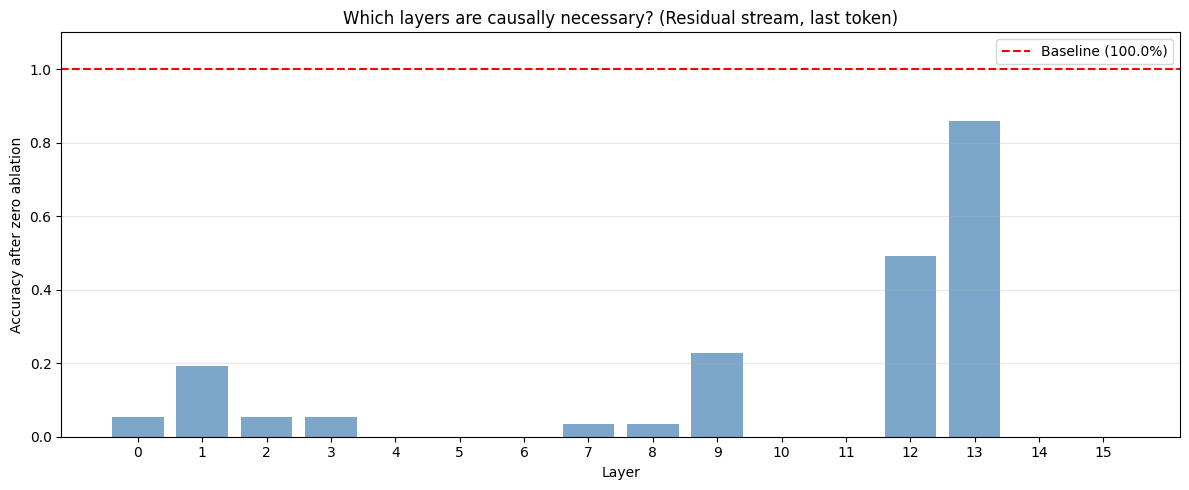


Layers with biggest performance drop:
  Layer  4: accuracy=0.0%  (drop: 100.0%)
  Layer  5: accuracy=0.0%  (drop: 100.0%)
  Layer  6: accuracy=0.0%  (drop: 100.0%)
  Layer 10: accuracy=0.0%  (drop: 100.0%)
  Layer 11: accuracy=0.0%  (drop: 100.0%)


In [6]:
import matplotlib.pyplot as plt

# Keys are (layer_index, token_position_id); sort by layer
layer_scores = sorted(ablation_scores.items(), key=lambda x: x[0][0])
layer_nums = [k[0] for k, _ in layer_scores]
scores = [v for _, v in layer_scores]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(layer_nums, scores, color="steelblue", alpha=0.7)
ax.axhline(y=baseline_accuracy, color="red", linestyle="--",
           label=f"Baseline ({baseline_accuracy:.1%})")
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy after zero ablation")
ax.set_title("Which layers are causally necessary? (Residual stream, last token)")
ax.set_xticks(layer_nums)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print the five layers with the largest accuracy drop
print("\nLayers with biggest performance drop:")
for (layer, _), score in sorted(ablation_scores.items(), key=lambda x: x[1])[:5]:
    drop = baseline_accuracy - score
    print(f"  Layer {layer:2d}: accuracy={score:.1%}  (drop: {drop:.1%})")

## Part 1b: Zero ablation in PCA feature space

Full zero ablation replaces the entire activation vector — a very destructive intervention. A more surgical question is: *does the task-relevant information live in the top principal components, or is it spread across the full space?*

We can answer this by fitting a `SubspaceFeaturizer` with the top-k PCA directions, then running `mode="replace"` again. With a subspace featurizer:

```
steered = error_term + rotation @ zeros   =   error_term
```

The error term (everything orthogonal to the top-k directions) is unchanged. Only the top-k PCA component is zeroed. If accuracy drops less than with full ablation, the task-irrelevant dimensions are carrying the model through.

In [7]:
# PARAMETERS
PCA_ANALYSIS_LAYER = 10   # which layer to focus on for PCA ablation
N_PCA_COMPONENTS = 10     # how many top principal components to zero

from causalab.neural.activations.collect import collect_features
from causalab.methods.trained_subspace.subspace import SubspaceFeaturizer

# --- Collect raw activations for PCA fitting ---
# Use a larger unfiltered sample so PCA directions are well-estimated
pca_fit_dataset = [different_symbol() for _ in range(256)]

pca_collect_target_map = build_residual_stream_targets(
    pipeline=pipeline,
    layers=[PCA_ANALYSIS_LAYER],
    token_positions=[last_token],
    mode="one_target_per_unit",
)
pca_collect_target = list(pca_collect_target_map.values())[0]
pca_unit = pca_collect_target.flatten()[0]

collected = collect_features(
    dataset=pca_fit_dataset,
    pipeline=pipeline,
    model_units=pca_collect_target.flatten(),
    batch_size=32,
)
raw_acts = collected[pca_unit.id]  # (N, hidden_size)
print(f"Collected {raw_acts.shape[0]} activations for PCA at layer {PCA_ANALYSIS_LAYER}")

# --- Fit PCA via SVD ---
centered = raw_acts - raw_acts.mean(dim=0, keepdim=True)
U, S, Vt = torch.linalg.svd(centered.float(), full_matrices=False)
rotation = Vt[:N_PCA_COMPONENTS].T  # (hidden_size, N_PCA_COMPONENTS)

explained = (S[:N_PCA_COMPONENTS] ** 2).sum() / (S ** 2).sum()
print(f"Top {N_PCA_COMPONENTS} components explain {explained:.1%} of variance")

# --- Attach PCA featurizer to a fresh target ---
pca_ablation_target_map = build_residual_stream_targets(
    pipeline=pipeline,
    layers=[PCA_ANALYSIS_LAYER],
    token_positions=[last_token],
    mode="one_target_per_unit",
)
pca_ablation_target = list(pca_ablation_target_map.values())[0]

for unit in pca_ablation_target.flatten():
    unit.set_featurizer(SubspaceFeaturizer(
        rotation_subspace=rotation,
        trainable=False,
        id="PCA",
    ))
    print(f"Featurizer set on {unit.id}: {unit.featurizer.n_features} features")


Processing batches:   0%|          | 0/8 [00:00<?, ?it/s]

Processing batches:  38%|███▊      | 3/8 [00:00<00:00, 28.39it/s]

Processing batches:  88%|████████▊ | 7/8 [00:00<00:00, 30.90it/s]

Collected 256 activations for PCA at layer 10


Top 10 components explain 66.2% of variance


Featurizer set on ResidualStream(Layer-10,block_output,Token-last_token): 10 features


In [8]:
# Run PCA zero ablation — zeros are N_PCA_COMPONENTS-dimensional (not hidden_size)
zero_pca = make_zero_features(pca_ablation_target, device=pipeline.model.device, dtype=torch.float32)
print(f"Zero vector shape: {list(zero_pca.values())[0].shape}  (only {N_PCA_COMPONENTS} dims, not full {pipeline.model.config.hidden_size})")

pca_outputs = run_steering_interventions(
    pipeline=pipeline,
    dataset=filtered_dataset,
    interchange_target=pca_ablation_target,
    steering_vectors=zero_pca,
    batch_size=32,
    output_scores=False,
    mode="replace",
)

pca_strings = pca_outputs.strings
pca_accuracy = sum(metric({"string": s}, l) for s, l in zip(pca_strings, labels)) / len(labels)

# Compare with full ablation at the same layer
full_ablation_key = next(k for k in ablation_scores if k[0] == PCA_ANALYSIS_LAYER)
full_ablation_score = ablation_scores[full_ablation_key]

print(f"\nLayer {PCA_ANALYSIS_LAYER} ablation comparison:")
print(f"  Baseline accuracy:                        {baseline_accuracy:.1%}")
print(f"  Full zero ablation (identity featurizer): {full_ablation_score:.1%}")
print(f"  PCA zero ablation ({N_PCA_COMPONENTS} components):         {pca_accuracy:.1%}")
print(f"\nThe top {N_PCA_COMPONENTS} PCA directions hold "
      f"{'most' if pca_accuracy < full_ablation_score + 0.10 else 'some'} "
      f"of the task-relevant signal — PCA ablation caused a "
      f"{baseline_accuracy - pca_accuracy:.1%} drop vs. "
      f"{baseline_accuracy - full_ablation_score:.1%} for full ablation.")

Zero vector shape: torch.Size([10])  (only 10 dims, not full 2048)



Layer 10 ablation comparison:
  Baseline accuracy:                        100.0%
  Full zero ablation (identity featurizer): 0.0%
  PCA zero ablation (10 components):         73.7%

The top 10 PCA directions hold some of the task-relevant signal — PCA ablation caused a 26.3% drop vs. 100.0% for full ablation.


## Part 2: Additive steering — push outputs toward a target

Instead of removing information, we can *add* a direction to steer the model toward a desired output:

```
steered_activation = base_activation + scale * steering_vector
```

**The idea:** compute the mean activation for examples where the correct answer is at symbol position 0 vs. position 1. The difference vector points from one class to the other. Adding it to an example should nudge the model to behave as if the answer were at a different position.

This is a simple but effective test: if the model's behavior can be controlled by adding a class-mean difference to a single layer, that layer is encoding the variable in a linearly separable way.

In [9]:
# PARAMETERS
STEER_LAYER = 10  # which layer to steer (try the most critical layer from the ablation)

# Build a fresh target at STEER_LAYER with an identity featurizer
steer_target_map = build_residual_stream_targets(
    pipeline=pipeline,
    layers=[STEER_LAYER],
    token_positions=[last_token],
    mode="one_target_per_unit",
)
steer_target = list(steer_target_map.values())[0]
steer_unit = steer_target.flatten()[0]

# Collect activations from the filtered dataset at STEER_LAYER
collected_steer = collect_features(
    dataset=filtered_dataset,
    pipeline=pipeline,
    model_units=steer_target.flatten(),
    batch_size=32,
)
activations = collected_steer[steer_unit.id]  # (n_examples, hidden_size)
print(f"Collected activations: {activations.shape}  (n_examples × hidden_size)")

# Split by answer position (which symbol slot holds the correct answer)
answer_positions = torch.tensor([
    ex["input"]["answer_position"] for ex in filtered_dataset
])
pos0_mask = answer_positions == 0
pos1_mask = answer_positions == 1

mean_pos0 = activations[pos0_mask].mean(dim=0)
mean_pos1 = activations[pos1_mask].mean(dim=0)

steering_vector_toward_pos1 = mean_pos1 - mean_pos0   # adds "pos1 direction"
steering_vector_toward_pos0 = mean_pos0 - mean_pos1   # adds "pos0 direction"

print(f"\nSteering vector norm: {steering_vector_toward_pos1.norm():.2f}")
print(f"Position-0 examples: {pos0_mask.sum().item()}")
print(f"Position-1 examples: {pos1_mask.sum().item()}")

Processing batches:   0%|          | 0/2 [00:00<?, ?it/s]

Collected activations: torch.Size([57, 2048])  (n_examples × hidden_size)

Steering vector norm: 1.89
Position-0 examples: 25
Position-1 examples: 32


In [10]:
# Broadcast steering: the same vector is added to every example
# (same vector for all → shape (hidden_size,) is automatically broadcast)
steering_dict = {
    steer_unit.id: steering_vector_toward_pos1.to(pipeline.model.device)
}

steered_outputs = run_steering_interventions(
    pipeline=pipeline,
    dataset=filtered_dataset,
    interchange_target=steer_target,
    steering_vectors=steering_dict,
    batch_size=32,
    output_scores=False,
    mode="add",  # ADD to base activations
)

steered_strings = steered_outputs.strings

changed = sum(1 for b, s in zip(baseline_strings, steered_strings) if b.strip() != s.strip())
print("Broadcast steering (toward position 1):")
print(f"  Outputs changed: {changed}/{len(baseline_strings)} ({changed/len(baseline_strings):.1%})")

print("\nExamples where output changed (showing up to 5):")
shown = 0
for i, (base, steered, pos) in enumerate(zip(baseline_strings, steered_strings, answer_positions)):
    if base.strip() != steered.strip() and shown < 5:
        inp = filtered_dataset[i]["input"]
        sym0, sym1 = inp.get("symbol0"), inp.get("symbol1")
        print(f"  Ex {i} (correct at pos {pos.item()}, symbols: {sym0}/{sym1}): "
              f"{base.strip()!r} → {steered.strip()!r}")
        shown += 1

Broadcast steering (toward position 1):
  Outputs changed: 17/57 (29.8%)

Examples where output changed (showing up to 5):
  Ex 5 (correct at pos 0, symbols: T/J): 'T' → 'J'
  Ex 10 (correct at pos 0, symbols: O/V): 'O' → 'V'
  Ex 12 (correct at pos 0, symbols: P/J): 'P' → 'J'
  Ex 16 (correct at pos 0, symbols: S/G): 'S' → 'G'
  Ex 19 (correct at pos 0, symbols: W/R): 'W' → 'R'


## Scaling experiment

The `scale` parameter controls how strongly the vector is applied:

```
steered = base + scale * steering_vector
```

`scale=0` is identical to the baseline. As scale increases, more outputs should flip. The accuracy-vs-scale curve tells you:

- **Threshold scale**: below what scale does the model mostly resist the intervention?
- **Saturation scale**: above what scale does output quality degrade (the model may start outputting incoherent tokens)?

Ideally you want a sharp transition from baseline accuracy to near-zero accuracy around scale=1, which indicates the vector has a clean, linear relationship with the output.

Testing scales:   0%|          | 0/6 [00:00<?, ?it/s]

Testing scales:  17%|█▋        | 1/6 [00:00<00:01,  4.15it/s]

Testing scales:  33%|███▎      | 2/6 [00:00<00:00,  4.15it/s]

Testing scales:  50%|█████     | 3/6 [00:00<00:00,  4.25it/s]

Testing scales:  67%|██████▋   | 4/6 [00:00<00:00,  4.38it/s]

Testing scales:  83%|████████▎ | 5/6 [00:01<00:00,  4.38it/s]

Testing scales: 100%|██████████| 6/6 [00:01<00:00,  4.41it/s]

Testing scales: 100%|██████████| 6/6 [00:01<00:00,  4.34it/s]

Scale    Accuracy     Changed   
------------------------------
0.00     100.0%       0         
0.25     98.2%        1         
0.50     86.0%        8         
1.00     70.2%        17        
2.00     57.9%        24        
4.00     56.1%        25        


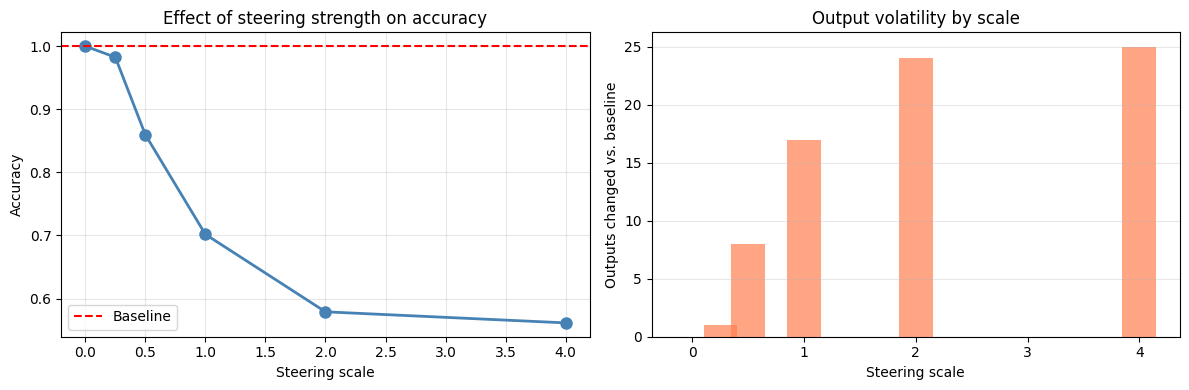

In [11]:
# PARAMETERS
SCALES = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]

scale_results = []
for scale in tqdm(SCALES, desc="Testing scales"):
    outputs = run_steering_interventions(
        pipeline=pipeline,
        dataset=filtered_dataset,
        interchange_target=steer_target,
        steering_vectors=steering_dict,
        batch_size=32,
        output_scores=False,
        mode="add",
        scale=scale,
    )
    output_strings = outputs.strings
    accuracy = sum(metric({"string": s}, l) for s, l in zip(output_strings, labels)) / len(labels)
    changed = sum(1 for b, s in zip(baseline_strings, output_strings) if b.strip() != s.strip())
    scale_results.append({"scale": scale, "accuracy": accuracy, "changed": changed})

# Print table
print(f"{'Scale':<8} {'Accuracy':<12} {'Changed':<10}")
print("-" * 30)
for r in scale_results:
    print(f"{r['scale']:<8.2f} {r['accuracy']:<12.1%} {r['changed']:<10}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

scales_plot = [r["scale"] for r in scale_results]
accuracies  = [r["accuracy"] for r in scale_results]
changes     = [r["changed"] for r in scale_results]

ax1.plot(scales_plot, accuracies, "o-", color="steelblue", linewidth=2, markersize=8)
ax1.axhline(y=baseline_accuracy, color="red", linestyle="--", label="Baseline")
ax1.set_xlabel("Steering scale")
ax1.set_ylabel("Accuracy")
ax1.set_title("Effect of steering strength on accuracy")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(scales_plot, changes, color="coral", alpha=0.7, width=0.3)
ax2.set_xlabel("Steering scale")
ax2.set_ylabel("Outputs changed vs. baseline")
ax2.set_title("Output volatility by scale")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Per-example steering vectors

So far we used **broadcast mode**: the same vector was added to every example. We can also use **per-example mode** by passing a tensor of shape `(n_examples, hidden_size)`.

Per-example steering lets you apply different interventions to each input. Here we flip the direction based on each example's answer position: examples where the correct answer is at position 0 get the "toward position 1" vector, and vice versa. The expected effect is that the model swaps its choice — examples that were originally correct should now be wrong, and vice versa.

In [12]:
n_examples = len(filtered_dataset)
hidden_size = pipeline.model.config.hidden_size

# Build one vector per example: push each example toward the other position
per_example_vectors = torch.zeros(n_examples, hidden_size)
for i, pos in enumerate(answer_positions):
    if pos == 0:
        per_example_vectors[i] = steering_vector_toward_pos1  # push toward pos1
    else:
        per_example_vectors[i] = steering_vector_toward_pos0  # push toward pos0

print(f"Per-example vectors: {per_example_vectors.shape}  (n_examples × hidden_size)")

# Per-example mode: pass a 2D tensor instead of a 1D broadcast vector
steering_dict_per_ex = {
    steer_unit.id: per_example_vectors.to(pipeline.model.device)
}

per_ex_outputs = run_steering_interventions(
    pipeline=pipeline,
    dataset=filtered_dataset,
    interchange_target=steer_target,
    steering_vectors=steering_dict_per_ex,
    batch_size=32,
    output_scores=False,
    mode="add",
)

per_ex_strings = per_ex_outputs.strings

changed = sum(1 for b, s in zip(baseline_strings, per_ex_strings) if b.strip() != s.strip())
accuracy = sum(metric({"string": s}, l) for s, l in zip(per_ex_strings, labels)) / len(labels)

print("\nPer-example steering results:")
print(f"  Baseline accuracy:  {baseline_accuracy:.1%}")
print(f"  After steering:     {accuracy:.1%}")
print(f"  Outputs changed:    {changed}/{n_examples} ({changed/n_examples:.1%})")

Per-example vectors: torch.Size([57, 2048])  (n_examples × hidden_size)



Per-example steering results:
  Baseline accuracy:  100.0%
  After steering:     47.4%
  Outputs changed:    30/57 (52.6%)


## What to look for

**From the zero ablation (Part 1):**

- A clear "critical window" of layers — usually the later half — where ablation drops accuracy dramatically. Early layers often show no effect because the answer symbol information has not yet been aggregated to the last-token position.
- PCA ablation drops accuracy less than full ablation. The gap tells you how much of the layer's computation is task-relevant vs. generic context. If PCA ablation and full ablation produce the same drop, the top components are capturing essentially all the signal.

**From additive steering (Part 2):**

- Outputs change primarily on examples where the answer is at position 0 (the direction added points away from their class). Examples at position 1 are already aligned with the vector.
- The scaling curve should show a smooth transition: near-baseline accuracy at low scale, dropping as scale increases. A sudden collapse at scale 1.0 suggests the mean-difference vector is strongly aligned with the task-relevant direction.
- Per-example steering flips the winning direction for each example individually, which should produce a more symmetric flip (both position-0 and position-1 examples change).

Try changing `STEER_LAYER` to the layer identified as most critical in the ablation, or sweep over multiple layers to see which one is most steerable.

---

## From exploration to analysis

The steering interventions above reveal how to **control individual examples**. The mean-difference vector you computed is ad hoc: it works for two discrete positions, but it does not account for the geometry of the activation space or generalize to tasks with many output classes.

A research question lives at the population level: **do steering paths through a learned manifold respect the causal geometry of the task?** Specifically — if you interpolate between the class-mean activations for output "A" and output "C" in a learned feature space, does the model's output distribution change smoothly and predictably along the path, or does it jump erratically?

Answering that requires:

- Pre-computed **subspace** artifacts (e.g., PCA or DAS directions) from the `subspace` analysis
- Pre-computed **activation manifold** artifacts (e.g., a spline fit to the PCA-projected data) from the `activation_manifold` analysis
- Evaluating paths across many centroid pairs, not just two
- Quantifying path quality via distortion metrics (efficiency, coherence, isometry)

This is exactly what the **`path_steering` analysis** does. Under the hood it calls the same `run_steering_interventions()` and `collect_grid_distributions()` you just used — packaged behind a Hydra config with filesystem discovery for upstream artifacts.

**Dependency chain:** `subspace` → `activation_manifold` → `path_steering`. Notebooks 04 and 05 produce the upstream artifacts. If you have already run those, Section 2 will discover them automatically. If not, a commented-out multi-step config below will build everything in one run.

## Running `path_steering` end-to-end

### Prerequisites

`path_steering` discovers its inputs by scanning the artifact directory:

```
artifacts/{task}/{model}/subspace/        ← produced by subspace analysis (notebook 04/05)
artifacts/{task}/{model}/activation_manifold/  ← produced by activation_manifold analysis (notebook 05)
```

**If you have already run notebooks 04 and 05**, those artifacts exist and the config below will find them automatically (`subspace: null`, `activation_manifold: null` = auto-discover).

**If you haven't**, uncomment the multi-step config in the next cell and run it first. It chains `locate → subspace → activation_manifold → path_steering` so everything is built in one go.

### Config fields

| Field | What it controls |
|---|---|
| `path_modes` | Types of steering paths: `geometric` (geodesics through learned manifold), `linear` (straight lines in PCA space) |
| `num_steps_along_path` | Discrete steps sampled along each path. More steps = finer resolution, slower. |
| `n_prompts` | Base prompts used per centroid pair. Higher = more stable statistics. |
| `n_eval_samples` | Total dataset size for computing class centroids. |
| `max_pairs` | Maximum (source, target) centroid pairs to evaluate. |
| `subspace` | Which subspace to use (e.g. `"pca_k16"`). `null` = auto-discover. |
| `activation_manifold` | Which manifold to use (e.g. `"spline_s0.0"`). `null` = auto-discover. |
| `eval_criteria` | Distortion metrics: `efficiency`, `coherence`, `isometry`, `conformal`. Empty list = skip metrics, only collect paths. |

In [ ]:
# ── FALLBACK: multi-step config ───────────────────────────────────────────────
# Uncomment and run this cell if you have NOT run notebooks 04/05 and need to
# build subspace + activation_manifold artifacts from scratch.
# This chains locate → subspace → activation_manifold → path_steering.
#
# multi_step_yaml = """\
# # @package _global_
# defaults:
#   - /base
#   - /task: MCQA
#   - /model: llama32_1b_instruct
#   - /analysis/locate
#   - /analysis/subspace
#   - /analysis/activation_manifold
#   - /analysis/path_steering
#   - _self_
#
# task:
#   n_train: 64
#   n_test: 16
#   enumerate_all: true
#
# locate:
#   method: interchange
#   mode: centroid
#   layers: [8, 10, 12]
# subspace:
#   method: pca
#   k_features: 16
#   layers: [10]
# activation_manifold:
#   method: spline
#   subspace: pca_k16
#   smoothness: 0.0
#   layers: [10]
# path_steering:
#   path_modes: [geometric, linear]
#   num_steps_along_path: 15
#   n_eval_samples: 50
#   n_prompts: 5
#   visualization:
#     figure_format: png
# """
#
# from causalab.io.configs import save_runner_config
# path = save_runner_config(multi_step_yaml, "mcqa_steering_full_pipeline")
# print(f"Multi-step config saved to: {path}")
# print("To run it: ./scripts/run_exp.sh mcqa_steering_full_pipeline")

print("Fallback config is commented out — uncomment above if you need to build upstream artifacts.")

In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: MCQA
  - /model: llama32_1b_instruct
  - /analysis/activation_manifold
  - /analysis/path_steering
  - _self_

task:
  enumerate_all: true
  target_variable: answer_position

activation_manifold:
  method: spline
  subspace: pca_k32
  smoothness: 0.0
  layers: [10]
  token_positions: [last_token]
  visualization:
    figure_format: png
path_steering:
  path_modes:
    - geometric
    - linear_subspace  # linear in PCA space; use "linear" if raw_features.safetensors exists
  num_steps_along_path: 15
  n_eval_samples: 50
  n_prompts: 5
  max_pairs: 50
  subspace: pca_k32
  activation_manifold: null  # auto-discover from artifacts/MCQA/llama32_1b_instruct/activation_manifold/
  eval_criteria: []          # set to [efficiency, coherence] to compute distortion metrics
  visualization:
    figure_format: png
"""

In [15]:
from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "steering_interventions_demo")
print(f"Written to {path}\n")

cfg = load_runner_config("steering_interventions_demo")
print("Full resolved config:")
print(OmegaConf.to_yaml(cfg))

Written to causalab/runner/configs/runner/steering_interventions_demo.yaml



Full resolved config:
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer_position
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
seed: 42
code_trace: false
experiment_root: artifacts/${task.name}/${model.id}
activation_manifold:
  _name_: activation_manifold
  _subdir: ${.method}_s${.smoothness}
  _output_dir: ${experiment_root}/activation_manifold/${._subdir}
  method: spline
  smoothness: 0.0
  intrinsic_dim: null
  n_grid: 21
  n_steer_examples: 50
  n_steer_interp: 0
  batch_size: 32
  subspace: pca_k32
  layers:
  - 10
  token_positions:
  - last_token
  manifold_intrinsic_coords: null
  skip_decoding_eval: false
  colormap: ${task.colormap}
  embedding_shuffle_seed: null
  visualization:
    figure_format: png
path_steering:
  _name_: path_steering
  _output_d

Run the analysis. This cell will raise a Python exception if the run fails, making the error visible rather than silently producing an empty artifact directory.

In [16]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "steering_interventions_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-04-21 19:35:47,120][__main__][INFO] - === Step: activation_manifold (activation_manifold) ===


[2026-04-21 19:35:54,955][__main__][INFO] - Running analysis: activation_manifold | target_variable: answer_position
[2026-04-21 19:35:54,960][__main__][INFO] - Resolved config:
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer_position
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
seed: 42
code_trace: false
experiment_root: artifacts/${task.name}/${model.id}
activation_manifold:
  _name_: activation_manifold
  _subdir: ${.method}_s${.smoothness}
  _output_dir: ${experiment_root}/activation_manifold/${._subdir}
  method: spline
  smoothness: 0.0
  intrinsic_dim: null
  n_grid: 21
  n_steer_examples: 50
  n_steer_interp: 0
  batch_size: 32
  subspace: pca_k32
  layers:
  - 10
  token_positions:
  - last_token
  manifold_intrinsic_coords: null
  skip_decoding_eval: 

[2026-04-21 19:35:55,356][causalab.runner.helpers][INFO] - Deduplicated train: 1000 -> 999 unique prompts
[2026-04-21 19:35:55,368][causalab.runner.helpers][INFO] - Dataset: 999 train, 50 test
[2026-04-21 19:35:55,368][causalab.analyses.activation_manifold.main][INFO] - Dataset generation: 0.4s
[2026-04-21 19:35:55,443][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.2-1B-Instruct (device=cuda)


`torch_dtype` is deprecated! Use `dtype` instead!


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


...

[2026-04-21 19:36:04,745][causalab.analyses.path_steering.main][INFO] - Evaluating 1 centroid pairs (1 total possible)
[2026-04-21 19:36:04,840][causalab.analyses.path_steering.main][INFO] - === Path mode: geometric ===
[2026-04-21 19:36:04,842][causalab.analyses.path_steering.main][INFO] - Loaded 1 pairs from cache


Saved figure to artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/geometric/pair_0_1.png
[2026-04-21 19:36:05,000][causalab.analyses.path_steering.path_visualization][INFO] - Saved 1 path visualizations to artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/geometric
[2026-04-21 19:36:05,000][causalab.analyses.path_steering.main][INFO] - === Path mode: linear_subspace ===


[2026-04-21 19:36:08,513][causalab.analyses.path_steering.main][INFO] - Collected pair distributions: torch.Size([1, 15, 5, 2])
Saved figure to artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/linear_subspace/pair_0_1.png
[2026-04-21 19:36:08,688][causalab.analyses.path_steering.path_visualization][INFO] - Saved 1 path visualizations to artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/linear_subspace
[2026-04-21 19:36:08,689][causalab.analyses.path_steering.main][INFO] - Skipping belief-space paths (missing output_manifold artifacts)
[2026-04-21 19:36:08,692][causalab.analyses.activation_manifold.utils][INFO] - Intrinsic ranges (99.7% coverage): dim0=[0.000, 1.000]
[2026-04-21 19:36:08,702][causalab.methods.spline.builders][INFO] - Computed 2 centroids from 512 samples (params: ['answer_position'])


[2026-04-21 19:36:08,819][causalab.io.plots.plot_3d_interactive][INFO] - Saved artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/3d_paths/0_1.html
[2026-04-21 19:36:08,837][causalab.methods.spline.builders][INFO] - Computed 2 centroids from 512 samples (params: ['answer_position'])


[2026-04-21 19:36:09,021][causalab.io.plots.pca_scatter][INFO] - Saved artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/3d_paths/0_1.png
[2026-04-21 19:36:09,021][causalab.analyses.path_steering.main][INFO] - Saved 1 3D path plots to artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token/spline_s0.0/answer_position/vis/paths/3d_paths
[2026-04-21 19:36:09,029][causalab.analyses.path_steering.main][INFO] - Evaluate analysis complete.


## Artifacts

For each `(subspace, activation_manifold)` combination discovered, the analysis saves results under:

```
artifacts/{task}/{model}/path_steering/{subspace}/{manifold}/
```

Key outputs:
- `metadata.json` — task, model, subspace/manifold names, all criteria results
- `results_summary.csv` — one row per metric
- `paths/{path_mode}/pair_distributions.safetensors` — output probability distributions along paths; shape `(n_pairs, n_steps, n_prompts, vocab_size)`
- `paths/{path_mode}/pairs.json` — which (source, target) centroid pairs were evaluated
- `vis/paths/{path_mode}/` — per-pair heatmap visualizations

In [17]:
# Derive artifact directory from the resolved config — never hardcode the path
artifact_dir = os.path.join(project_root, cfg.experiment_root, "path_steering")
print(f"Artifact directory: {artifact_dir}\n")

if os.path.isdir(artifact_dir):
    for ss_dir in sorted(os.listdir(artifact_dir)):
        ss_path = os.path.join(artifact_dir, ss_dir)
        if not os.path.isdir(ss_path):
            continue
        for m_dir in sorted(os.listdir(ss_path)):
            m_path = os.path.join(ss_path, m_dir)
            if os.path.isdir(m_path):
                print(f"  {ss_dir}/{m_dir}")
                print(f"    Contents: {sorted(os.listdir(m_path))}")
else:
    print("Artifact directory does not exist yet — run the cell above first.")

Artifact directory: artifacts/MCQA/llama32_1b_instruct/path_steering

  pca_k32/L10_last_token
    Contents: ['spline_s0.0']


### Metadata and summary

The `metadata.json` confirms which subspace/manifold combination was evaluated and what criteria (if any) were computed. The `results_summary.csv` gives one row per metric so results are easy to compare across runs.

In [18]:
import json

# Find first available (subspace, manifold) result directory
result_dir = None
if os.path.isdir(artifact_dir):
    ss_dirs = sorted(d for d in os.listdir(artifact_dir) if os.path.isdir(os.path.join(artifact_dir, d)))
    for ss_sub in ss_dirs:
        ss_path = os.path.join(artifact_dir, ss_sub)
        m_dirs = sorted(d for d in os.listdir(ss_path) if os.path.isdir(os.path.join(ss_path, d)))
        if m_dirs:
            result_dir = os.path.join(ss_path, m_dirs[0])
            print(f"Loading results from: {ss_sub}/{m_dirs[0]}")
            break

if result_dir is not None:
    # Load metadata
    meta_path = os.path.join(result_dir, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            metadata = json.load(f)
        print(f"\nTask:     {metadata.get('task')}")
        print(f"Model:    {metadata.get('model')}")
        print(f"Subspace: {metadata.get('subspace')}")
        print(f"Manifold: {metadata.get('activation_manifold')}")
        print(f"N eval:   {metadata.get('n_eval_samples')}")
        print(f"Path modes evaluated: {metadata.get('path_modes')}")
        criteria = metadata.get("criteria", {})
        if criteria:
            print("\nCriteria results:")
            for k, v in criteria.items():
                print(f"  {k}: {v}")
        else:
            print("\nNo distortion metrics computed (eval_criteria was empty).")
            print("Set eval_criteria: [efficiency, coherence] in the config and rerun to compute them.")

    # Load results summary CSV
    csv_path = os.path.join(result_dir, "results_summary.csv")
    if os.path.exists(csv_path):
        with open(csv_path) as f:
            print(f"\nresults_summary.csv:\n{f.read()}")
else:
    print("No results found. Run the experiment cell first.")

Loading results from: pca_k32/L10_last_token


### Pair distributions

The core artifact is `pair_distributions.safetensors` — a tensor of shape `(n_pairs, n_steps, n_prompts, vocab_size)` recording the full output probability distribution at every step along every path for every base prompt.

This is conceptually the same data the `collect_grid_distributions()` function you used in Section 1 would produce — but saved across many centroid pairs and both path modes. The per-pair heatmap visualizations in `vis/paths/{path_mode}/` show how the top output tokens' probabilities evolve along each path.

In [19]:
if result_dir is not None:
    paths_dir = os.path.join(result_dir, "paths")
    if os.path.isdir(paths_dir):
        for path_mode in sorted(os.listdir(paths_dir)):
            mode_dir = os.path.join(paths_dir, path_mode)
            if not os.path.isdir(mode_dir):
                continue

            dist_path = os.path.join(mode_dir, "pair_distributions.safetensors")
            pairs_path = os.path.join(mode_dir, "pairs.json")

            if os.path.exists(dist_path):
                from safetensors.torch import load_file as _load_safetensors
                tensors = _load_safetensors(dist_path)
                dists = tensors["pair_distributions"]
                # shape: (n_pairs, n_steps, n_prompts, vocab_size)

                print(f"\n--- {path_mode} mode ---")
                print(f"  Distributions shape: {list(dists.shape)}")
                print(f"  ({dists.shape[0]} pairs × {dists.shape[1]} steps × "
                      f"{dists.shape[2]} prompts × vocab_size={dists.shape[3]})")

                # Load pair labels
                if os.path.exists(pairs_path):
                    with open(pairs_path) as f:
                        pairs_meta = json.load(f)
                    values = pairs_meta.get("values", [])
                    pairs = pairs_meta.get("pairs", [])
                    if pairs:
                        si, ei = pairs[0]
                        src_label = values[si] if si < len(values) else str(si)
                        tgt_label = values[ei] if ei < len(values) else str(ei)
                        print(f"  First pair: '{src_label}' → '{tgt_label}'")

                # Entropy along first pair's path (averaged over prompts)
                first_pair = dists[0]  # (n_steps, n_prompts, vocab_size)
                entropies = []
                for step_dists in first_pair:
                    avg_dist = step_dists.float().mean(dim=0)  # (vocab_size,)
                    entropy = -(avg_dist * torch.log(avg_dist + 1e-10)).sum().item()
                    entropies.append(entropy)
                print(f"  Output entropy along first pair: "
                      f"{entropies[0]:.2f} → {entropies[-1]:.2f}")
    else:
        print("No paths directory found — check that the run completed successfully.")
else:
    print("No results loaded — run the experiment cell first.")

No paths directory found — check that the run completed successfully.


### Path heatmaps

The per-pair heatmaps in `vis/paths/{path_mode}/` visualize how output token probabilities evolve along each steering path. Each row in the heatmap is one step along the path; each column is one of the output token classes (e.g., answer symbols A, B, C).

A **good steering path** should show:
1. The source-class probability starting high and falling to near zero
2. The target-class probability rising from near zero to high
3. A smooth, monotone transition (not erratic jumps)

**Geometric paths** (geodesics through the learned manifold) often produce smoother transitions than **linear paths** (straight lines in PCA space), because the manifold's intrinsic geometry better captures the curved surface on which class representations live.

In [20]:
from glob import glob
from IPython.display import Image, display

if result_dir is not None:
    vis_base = os.path.join(result_dir, "vis", "paths")
    if os.path.isdir(vis_base):
        for path_mode in sorted(os.listdir(vis_base)):
            mode_vis_dir = os.path.join(vis_base, path_mode)
            if not os.path.isdir(mode_vis_dir):
                continue
            # Show up to the first 2 pair images per mode
            heatmaps = sorted(glob(os.path.join(mode_vis_dir, "*.png")))[:2]
            if heatmaps:
                print(f"\n--- {path_mode} path heatmaps ({len(heatmaps)} of "
                      f"{len(sorted(glob(os.path.join(mode_vis_dir, '*.png'))))} shown) ---")
                for hp in heatmaps:
                    display(Image(filename=hp))
            else:
                print(f"\n{path_mode}: no PNG heatmaps found in {mode_vis_dir}")
    else:
        print(f"No vis/paths directory found under {result_dir}")
else:
    print("No results loaded — run the experiment cell first.")

No vis/paths directory found under artifacts/MCQA/llama32_1b_instruct/path_steering/pca_k32/L10_last_token


## Takeaway

You have now seen steering at two levels of abstraction:

**Section 1 — hand-crafted steering:**
- `make_zero_features` + `mode="replace"` → layer-by-layer ablation to identify critical layers
- Mean-difference vectors + `mode="add"` → shift model outputs toward a target class
- `scale` controls intervention strength; per-example tensors allow conditional control
- Key functions: `run_steering_interventions()`, `make_zero_features()`, `collect_features()`

**Section 2 — population-scale analysis via `path_steering`:**
- Loads pre-computed `subspace` and `activation_manifold` artifacts automatically
- Builds centroid pairs from the training data in the appropriate feature space
- Evaluates steering paths (geodesics vs. linear interpolation) across all pairs
- The `pair_distributions` artifact is the population-level version of the per-example outputs you collected in Section 1 — it shows how output probabilities evolve along each path

**Reading the pair distribution heatmaps:**
- Clean paths show a single dominant class at the start that transitions smoothly to a different dominant class at the end
- Erratic paths (multiple classes competing throughout) suggest the learned manifold does not cleanly separate the task geometry at this layer
- Geometric paths that are smoother than linear paths confirm the manifold is capturing genuine curvature in the representation space

**What comes next:**
- Set `eval_criteria: [efficiency, coherence]` in the config and rerun to quantify path quality numerically
- Run the `pullback` analysis to optimize steering paths by minimizing path distortion via Riemannian gradient descent
- Compare `geometric` and `linear` path modes — if they perform similarly, the manifold's curvature may not be significant at this layer

For the full `path_steering` walkthrough including isometry and conformal metrics: `causalab/analyses/path_steering/`.